# CH 6 - Limitations of Data Out-of-Sample Testing Methods

## Objectif pédagogique

Ce notebook transforme la section **Limitations of Data Out-of-Sample Testing Methods** en expérience concrète Python.

L'idée centrale est simple :

> Le test **Out-of-Sample** protège contre le **biais de minage de données**, mais cette protection est fragile, coûteuse, et facile à contaminer.

Dans ce notebook, on va illustrer trois limites :

| Limite | Intuition | Risque pratique |
|---|---|---|
| **Contamination OOS** | Une donnée de validation n'est vierge qu'une fois | Retester après ajustement réintroduit le biais |
| **Sacrifice de données IS** | Réserver du OOS réduit l'historique utilisé pour apprendre | Moins de puissance pour détecter un vrai signal faible |
| **Arbitraire du split** | 50/50, 70/30 ou 80/20 changent les conclusions | Une stratégie peut réussir ou échouer selon le découpage |

Nous allons simuler un univers de règles de trading artificielles pour voir comment ces problèmes apparaissent.


## 1. L'idée EBTA en une phrase

Dans un backtest sérieux, le segment **Out-of-Sample** doit jouer le rôle d'un examen final.

> Une donnée **OOS** n'est réellement indépendante que si elle n'a jamais influencé la conception, la sélection ou l'ajustement de la stratégie.

Dès que le trader observe le résultat OOS, modifie sa règle, puis reteste sur le même OOS, ce segment cesse d'être une validation indépendante.

Mathématiquement, le problème est le suivant :

$$
\text{Performance observée OOS après retests}
=
\text{Signal réel}
+
\text{Chance sélectionnée}
$$

Le danger est que le trader pense mesurer le **signal réel**, alors qu'il a progressivement sélectionné une forme de chance adaptée à son OOS.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

def annualized_mean(monthly_returns):
    # Approximation simple du rendement annualisé à partir de rendements mensuels.
    return monthly_returns.mean(axis=0) * 12

def simulate_rules(
    n_months=240,
    n_rules=500,
    true_edge_mean=0.00,
    true_edge_std=0.002,
    noise_std=0.04,
    seed=None
):
    # Simule des rendements mensuels pour un univers de règles artificielles.
    rng = np.random.default_rng(seed)
    monthly_edges = rng.normal(true_edge_mean, true_edge_std, size=n_rules)
    noise = rng.normal(0, noise_std, size=(n_months, n_rules))
    returns = monthly_edges + noise
    true_edges_annual = monthly_edges * 12
    return returns, true_edges_annual

returns, true_edges = simulate_rules(seed=1)

print("Shape des rendements simulés :", returns.shape)
print("Edge réel annualisé moyen :", round(true_edges.mean(), 4))
print("Meilleur edge réel annualisé :", round(true_edges.max(), 4))


Shape des rendements simulés : (240, 500)
Edge réel annualisé moyen : -0.0009
Meilleur edge réel annualisé : 0.0744


## 2. Protocole propre : In-Sample puis un seul test OOS

Dans un protocole propre :

1. On cherche la meilleure règle sur le segment **In-Sample**.
2. On verrouille la règle.
3. On la teste une seule fois sur le segment **Out-of-Sample**.

La performance OOS de cette règle donne une estimation plus honnête que la performance IS, car elle n'a pas servi à sélectionner la règle.

Mais même ici, il reste deux fragilités :

- le segment OOS peut être trop court ;
- le choix du découpage peut changer la conclusion.


In [2]:
def single_oos_test(returns, true_edges, train_ratio=0.70):
    # Sélectionne la meilleure règle en IS, puis mesure sa performance OOS une seule fois.
    n_months = returns.shape[0]
    split = int(n_months * train_ratio)

    is_returns = returns[:split]
    oos_returns = returns[split:]

    is_perf = annualized_mean(is_returns)
    oos_perf = annualized_mean(oos_returns)

    selected_rule = np.argmax(is_perf)

    result = {
        "train_ratio": train_ratio,
        "selected_rule": selected_rule,
        "is_perf_selected": is_perf[selected_rule],
        "oos_perf_selected": oos_perf[selected_rule],
        "true_edge_selected": true_edges[selected_rule],
        "best_is_perf": is_perf.max(),
        "best_true_edge": true_edges.max(),
    }
    return result

result = single_oos_test(returns, true_edges, train_ratio=0.70)
pd.DataFrame([result]).T.rename(columns={0: "valeur"})


,valeur
train_ratio,0.700000
selected_rule,449.000000
is_perf_selected,0.140368
oos_perf_selected,0.146457
true_edge_selected,0.051143
best_is_perf,0.140368
best_true_edge,0.074401


### Lecture trading

La règle gagnante en **In-Sample** n'est pas forcément celle qui a le meilleur **mérite réel**.

Pourquoi ?

Parce que la règle sélectionnée maximise :

$$
P_{\text{observée}}
=
P_{\text{réelle}}
+
H
$$

où $H$ représente la chance historique.

Le test OOS sert précisément à vérifier si la règle reste performante quand la chance sélectionnée en IS ne se répète pas forcément.


## 3. Contamination : quand le trader reteste plusieurs fois sur le même OOS

Maintenant, simulons un comportement très courant :

1. Le trader teste un lot de règles.
2. Il regarde le résultat OOS.
3. Il ajuste, rejette, relance, modifie.
4. Il finit par choisir la règle qui marche le mieux sur ce même OOS.

En apparence, il fait encore du OOS.

En réalité, il transforme progressivement l'OOS en second In-Sample.

> Le segment OOS devient contaminé dès qu'il influence la décision de recherche.


In [3]:
def contaminated_oos_search(
    returns,
    true_edges,
    train_ratio=0.70,
    n_attempts=50,
    candidates_per_attempt=20,
    seed=123
):
    # Simule une contamination OOS.
    # À chaque tentative, le trader teste un petit groupe de règles candidates.
    # Il regarde leur OOS, puis continue.
    # À la fin, il retient implicitement la règle qui a eu le meilleur OOS parmi toutes les tentatives.
    n_months, n_rules = returns.shape
    rng = np.random.default_rng(seed)
    split = int(n_months * train_ratio)

    is_returns = returns[:split]
    oos_returns = returns[split:]

    is_perf = annualized_mean(is_returns)
    oos_perf = annualized_mean(oos_returns)

    history = []

    for attempt in range(1, n_attempts + 1):
        candidates = rng.choice(n_rules, size=candidates_per_attempt, replace=False)
        best_candidate = candidates[np.argmax(is_perf[candidates])]

        history.append({
            "attempt": attempt,
            "selected_rule": best_candidate,
            "is_perf": is_perf[best_candidate],
            "oos_perf": oos_perf[best_candidate],
            "true_edge": true_edges[best_candidate]
        })

    df = pd.DataFrame(history)
    best_after_contamination = df.loc[df["oos_perf"].idxmax()]
    return df, best_after_contamination

contam_df, best_contam = contaminated_oos_search(
    returns,
    true_edges,
    train_ratio=0.70,
    n_attempts=80,
    candidates_per_attempt=25,
    seed=7
)

best_contam


attempt            6.000000
selected_rule    283.000000
is_perf            0.078103
oos_perf           0.152805
true_edge          0.011664
Name: 5, dtype: float64

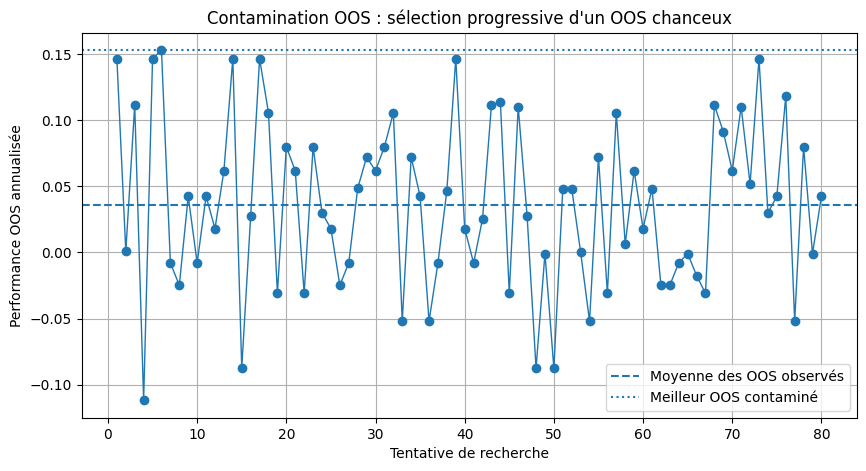

Meilleure performance OOS observée après contamination : 0.1528
Edge réel de cette règle : 0.0117


In [4]:
plt.figure(figsize=(10, 5))
plt.plot(contam_df["attempt"], contam_df["oos_perf"], marker="o", linewidth=1)
plt.axhline(contam_df["oos_perf"].mean(), linestyle="--", label="Moyenne des OOS observés")
plt.axhline(best_contam["oos_perf"], linestyle=":", label="Meilleur OOS contaminé")
plt.title("Contamination OOS : sélection progressive d'un OOS chanceux")
plt.xlabel("Tentative de recherche")
plt.ylabel("Performance OOS annualisée")
plt.legend()
plt.grid(True)
plt.show()

print("Meilleure performance OOS observée après contamination :", round(best_contam["oos_perf"], 4))
print("Edge réel de cette règle :", round(best_contam["true_edge"], 4))


### Eurêka

> Plus tu regardes le même OOS pour décider quoi modifier, plus tu le transformes en terrain d'optimisation.

Le problème n'est pas seulement technique.

Il est psychologique.

Après un échec OOS, le trader veut naturellement comprendre, corriger, améliorer, retester. Mais ce cycle rend le résultat suivant moins crédible.

En pratique :

$$
\text{OOS utilisé une fois}
\approx
\text{validation}
$$

$$
\text{OOS utilisé plusieurs fois}
\approx
\text{optimisation déguisée}
$$


## 4. Sacrifice de l'information : plus de OOS signifie moins de données pour apprendre

Réserver une partie de l'historique au test OOS est une bonne protection.

Mais cette protection a un coût.

Si le signal est faible, réduire le nombre d'observations **In-Sample** diminue la capacité de l'algorithme à distinguer le vrai signal du bruit.

On va comparer plusieurs proportions de split :

| Split | In-Sample | Out-of-Sample |
|---|---:|---:|
| 50/50 | 50 % | 50 % |
| 70/30 | 70 % | 30 % |
| 80/20 | 80 % | 20 % |
| 90/10 | 90 % | 10 % |


In [5]:
def compare_splits(n_simulations=300, train_ratios=(0.50, 0.70, 0.80, 0.90), seed=99):
    # Compare l'effet de plusieurs splits IS/OOS sur la performance OOS.
    rng = np.random.default_rng(seed)
    rows = []

    for sim in range(n_simulations):
        sim_returns, sim_true_edges = simulate_rules(seed=rng.integers(0, 1_000_000))

        for ratio in train_ratios:
            res = single_oos_test(sim_returns, sim_true_edges, train_ratio=ratio)
            rows.append({
                "simulation": sim,
                "train_ratio": ratio,
                "is_months": int(sim_returns.shape[0] * ratio),
                "oos_months": sim_returns.shape[0] - int(sim_returns.shape[0] * ratio),
                "is_perf_selected": res["is_perf_selected"],
                "oos_perf_selected": res["oos_perf_selected"],
                "true_edge_selected": res["true_edge_selected"],
            })

    return pd.DataFrame(rows)

split_df = compare_splits()
summary = split_df.groupby("train_ratio").agg(
    is_months=("is_months", "first"),
    oos_months=("oos_months", "first"),
    avg_is_perf=("is_perf_selected", "mean"),
    avg_oos_perf=("oos_perf_selected", "mean"),
    avg_true_edge=("true_edge_selected", "mean"),
    std_oos_perf=("oos_perf_selected", "std"),
).reset_index()

summary


,train_ratio,is_months,oos_months,avg_is_perf,avg_oos_perf,avg_true_edge,std_oos_perf
0,0.5,120,120,0.151260,0.031322,0.035107,0.048667
1,0.7,168,72,0.133465,0.034081,0.040303,0.060892
2,0.8,192,48,0.126515,0.037810,0.039548,0.071052
3,0.9,216,24,0.121488,0.045861,0.042525,0.096722


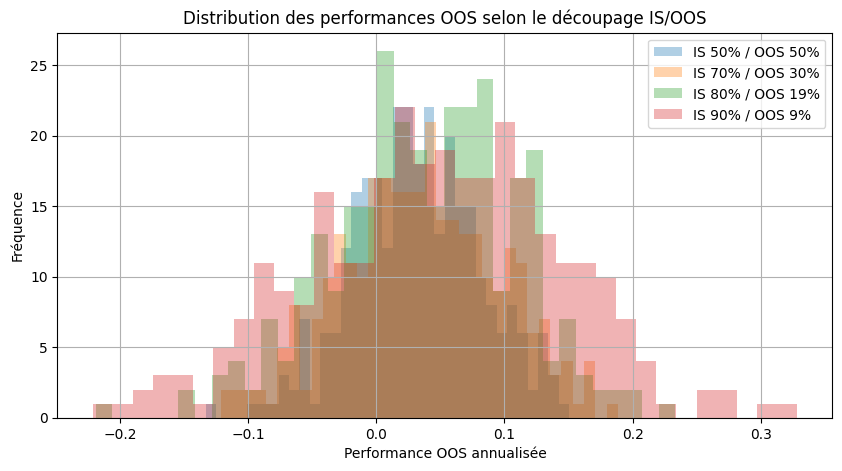

In [6]:
plt.figure(figsize=(10, 5))
for ratio in sorted(split_df["train_ratio"].unique()):
    data = split_df.loc[split_df["train_ratio"] == ratio, "oos_perf_selected"]
    plt.hist(data, bins=35, alpha=0.35, label=f"IS {int(ratio*100)}% / OOS {int((1-ratio)*100)}%")

plt.title("Distribution des performances OOS selon le découpage IS/OOS")
plt.xlabel("Performance OOS annualisée")
plt.ylabel("Fréquence")
plt.legend()
plt.grid(True)
plt.show()


### Lecture des résultats

Un split plus généreux en **In-Sample** donne plus de données pour sélectionner la règle.

Mais il laisse moins de données pour mesurer sa performance OOS.

Donc il y a un arbitrage :

- beaucoup de **IS** : meilleure recherche, mais validation OOS plus fragile ;
- beaucoup de **OOS** : meilleure validation, mais recherche IS moins puissante.

Il n'existe pas de proportion magique universelle.

C'est exactement l'une des critiques d'Aronson : le découpage IS/OOS repose souvent sur un choix pratique, pas sur une vérité théorique absolue.


## 5. Arbitraire du partitionnement : même ratio, conclusions différentes

Un autre problème est que deux splits 70/30 peuvent produire des conclusions différentes selon **où** se trouve la coupure.

Dans un marché non stationnaire, certaines périodes contiennent :

- un régime de tendance ;
- un régime de range ;
- une crise ;
- une phase de volatilité compressée ;
- une phase de volatilité explosive.

Un OOS mal situé peut donc donner une conclusion trop pessimiste ou trop optimiste.


In [7]:
def rolling_split_sensitivity(
    n_months=240,
    n_rules=500,
    train_months=120,
    oos_months=36,
    step=6,
    seed=2024
):
    # Analyse la sensibilité du résultat OOS selon la position du split.
    sim_returns, sim_true_edges = simulate_rules(
        n_months=n_months,
        n_rules=n_rules,
        seed=seed
    )

    rows = []
    start_points = range(0, n_months - train_months - oos_months + 1, step)

    for start in start_points:
        train_start = start
        train_end = start + train_months
        oos_start = train_end
        oos_end = oos_start + oos_months

        is_returns = sim_returns[train_start:train_end]
        oos_returns = sim_returns[oos_start:oos_end]

        is_perf = annualized_mean(is_returns)
        oos_perf = annualized_mean(oos_returns)

        selected = np.argmax(is_perf)

        rows.append({
            "train_start": train_start,
            "train_end": train_end,
            "oos_start": oos_start,
            "oos_end": oos_end,
            "selected_rule": selected,
            "is_perf": is_perf[selected],
            "oos_perf": oos_perf[selected],
            "true_edge": sim_true_edges[selected],
        })

    return pd.DataFrame(rows)

sensitivity_df = rolling_split_sensitivity()
sensitivity_df.head()


,train_start,train_end,oos_start,oos_end,selected_rule,is_perf,oos_perf,true_edge
0,0,120,120,156,72,0.139574,-0.017938,0.047365
1,6,126,126,162,227,0.165866,0.092828,0.017025
2,12,132,132,168,227,0.179702,0.020719,0.017025
3,18,138,138,174,227,0.171719,-0.002497,0.017025
4,24,144,144,180,227,0.159233,0.023188,0.017025


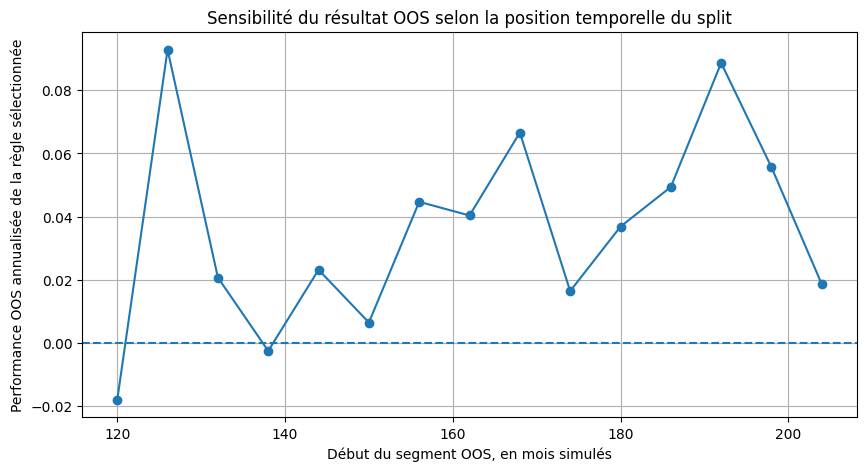

Performance OOS min : -0.0179
Performance OOS max : 0.0928
Écart max-min : 0.1108


In [8]:
plt.figure(figsize=(10, 5))
plt.plot(sensitivity_df["oos_start"], sensitivity_df["oos_perf"], marker="o")
plt.axhline(0, linestyle="--")
plt.title("Sensibilité du résultat OOS selon la position temporelle du split")
plt.xlabel("Début du segment OOS, en mois simulés")
plt.ylabel("Performance OOS annualisée de la règle sélectionnée")
plt.grid(True)
plt.show()

print("Performance OOS min :", round(sensitivity_df["oos_perf"].min(), 4))
print("Performance OOS max :", round(sensitivity_df["oos_perf"].max(), 4))
print("Écart max-min :", round(sensitivity_df["oos_perf"].max() - sensitivity_df["oos_perf"].min(), 4))


### Interprétation

La même méthode de sélection peut produire un bon ou un mauvais résultat OOS selon la période de validation.

Cela ne veut pas dire que l'OOS est inutile.

Cela veut dire qu'un seul split OOS est souvent insuffisant pour juger une stratégie de trading.

D'où l'intérêt de méthodes plus robustes :

- **Walk-Forward Testing** ;
- validation sur plusieurs régimes ;
- stress tests ;
- bootstrap ;
- **White's Reality Check** ;
- tests de robustesse des paramètres.


## 6. Exemple pratique trading : mauvaise et bonne discipline OOS

### Mauvaise discipline

```text
1. Je crée une stratégie.
2. Je l'optimise sur 2018-2022.
3. Je la teste sur 2023.
4. Elle échoue.
5. Je change les paramètres.
6. Je reteste sur 2023.
7. Je recommence jusqu'à ce que 2023 soit bon.
```

Ce protocole donne l'impression d'être scientifique, mais il contamine 2023.

### Bonne discipline

```text
1. Je définis la stratégie, les paramètres, les exits, le risk management.
2. Je teste et optimise uniquement sur IS.
3. Je verrouille tout par écrit.
4. Je teste une seule fois sur OOS.
5. Si OOS échoue, je note l'échec.
6. Je ne réutilise pas ce même OOS comme preuve indépendante.
```

Le vrai niveau élite, ce n'est pas d'avoir un OOS vert.

C'est de respecter le protocole même quand le résultat OOS fait mal.


## 7. Checklist EBTA pour protéger ton OOS

| Question | Réponse attendue |
|---|---|
| Les paramètres ont-ils été verrouillés avant le OOS ? | Oui |
| Le OOS a-t-il été regardé une seule fois ? | Oui |
| Le résultat OOS a-t-il influencé une modification ? | Non |
| Le split a-t-il été choisi avant les résultats ? | Oui |
| Plusieurs régimes de marché ont-ils été testés ? | Idéalement oui |
| Une méthode complémentaire corrige-t-elle le data mining ? | WRC, bootstrap, walk-forward |

> L'OOS ne sauve pas une recherche indisciplinée. Il protège seulement un protocole déjà propre.


## 8. Synthèse finale

Les tests **Out-of-Sample** sont indispensables, mais ils ne sont pas magiques.

Ils ont trois grandes limites :

1. **Ils se contaminent vite** : une fois observés, ils influencent les décisions futures.
2. **Ils coûtent de la donnée** : moins de données restent disponibles pour découvrir un signal réel.
3. **Ils dépendent du découpage** : un split arbitraire peut donner une conclusion instable.

> L'Eurêka final : le test OOS n'est pas une garantie de vérité. C'est un outil de discipline. Sa valeur dépend moins de la formule que du comportement du chercheur.

Dans une démarche EBTA, la vraie question n'est pas seulement :

**"Est-ce que ma stratégie passe le OOS ?"**

Mais plutôt :

**"Est-ce que mon protocole empêche vraiment mon cerveau de contaminer le OOS ?"**


## Annexe — Texte source fourni

### **CH 6 : LIMITATIONS OF DATA OUT-OF-SAMPLE TESTING METHODS**

Bien que les tests hors-échantillon (Out-of-Sample - OOS) soient considérés comme un remède essentiel au biais de minage de données, David Aronson souligne qu'ils comportent des faiblesses structurelles et méthodologiques importantes qui peuvent compromettre leur efficacité.

#### **Idées clés :**
*   **Durée de vie éphémère (Contamination) :** Une donnée hors-échantillon perd son statut de "donnée vierge" dès qu'elle est utilisée pour évaluer une règle ; elle ne peut plus fournir d'estimation impartiale par la suite.
*   **Réduction de la puissance de recherche :** Isoler des données pour le test OOS réduit mécaniquement la quantité de données disponibles pour identifier des motifs (patterns) réels, ce qui est préjudiciable quand le signal est faible.
*   **Arbitraire du partitionnement :** Le choix de la proportion de données à allouer à l'entraînement (In-Sample) par rapport au test (Out-of-Sample) ne repose sur aucune base théorique solide.
*   **Sensibilité des résultats :** La performance finale d'une stratégie peut varier considérablement en fonction de la manière dont les segments IS et OOS ont été découpés.

#### **Référence :**
*Limitations of Data Out-of-Sample Testing Methods*, Chapitre 6, pages 323 à 324.

#### **Citation Directe :**
« First and foremost, the virginal status of the data reserved for out-of-sample testing has a short life span. It is lost as soon as it is used one time. » (Page 323).

---

#### **Vision Macro :**
L'enjeu est de comprendre que les données historiques sont une ressource précieuse et finie. David Aronson explique que le test hors-échantillon est une protection contre l'auto-déception, mais c'est une protection coûteuse. En trading, contrairement aux sciences expérimentales, nous ne pouvons pas générer de nouvelles données à volonté. Utiliser une partie de l'historique pour la validation "consomme" cette donnée. Si le trader utilise l'échec d'un test OOS pour modifier sa règle et la retester sur le même échantillon, il commet un "snooping" (furetage) qui réintroduit le biais de minage dans la zone censée être protégée.

---

#### **Vision Micro :**
Le texte identifie trois limitations techniques majeures :

1.  **Le problème de la "Sérénité Perdue" (Data Contamination) :** Idéalement, une donnée OOS ne doit être touchée qu'une seule fois. Si, après un mauvais résultat OOS, vous retournez ajuster vos paramètres (back to the laboratory), la donnée OOS n'est plus indépendante. Elle devient une partie implicite du processus de sélection, et le biais de minage s'y infiltre.
2.  **Le sacrifice de l'information :** Pour que le minage de données soit efficace, il faut un maximum d'observations ($N$ élevé) pour que les motifs réels se distinguent du bruit. En réservant 30 % des données pour le test OOS, vous réduisez la capacité de l'algorithme à découvrir des relations complexes lors de la phase In-Sample.
3.  **L'absence de protocole standard pour le découpage :** Aronson note que décider de mettre 50/50, 70/30 ou 80/20 entre IS et OOS est souvent une décision "au pif" (seat-of-the-pants call). Comme les marchés ne sont pas stationnaires, un découpage malchanceux peut isoler une période atypique dans le segment OOS, rendant le test non représentatif du futur.

---

#### **Résumé Simplifié :**
Le test hors-échantillon est comme un examen final. Si vous échouez et que vous demandez à repasser le *même* examen après avoir révisé les questions, votre nouvelle note ne prouve plus votre intelligence, mais juste votre capacité à mémoriser les réponses. De plus, cacher des données à l'ordinateur pendant qu'il cherche une stratégie, c'est comme lui demander de résoudre un puzzle alors qu'il manque des pièces.

---

#### **Exemples du livre pour mieux comprendre :**
*   **L'analogie de la virginité des données :** Aronson utilise le terme « virginal status » pour marteler qu'une donnée ne peut être "neuve" qu'une seule fois. Une fois qu'une règle a été testée sur un segment de prix, la connaissance de ce résultat influence inévitablement les décisions futures du chercheur.
*   **Le biais de représentativité :** Si un test OOS est effectué uniquement sur une période de marché baissier (Bear Market) alors que la stratégie a été conçue en marché haussier (Bull Market), l'échec ne sera pas dû à la règle mais à un échantillon de test non représentatif.

---

#### **Actions Concrètes :**
*   **Discipline de fer :** Ne regardez jamais vos données de validation avant d'avoir verrouillé définitivement tous les paramètres de votre stratégie.
*   **Privilégier le Walk-Forward :** Pour atténuer l'arbitraire du découpage, utilisez des fenêtres glissantes qui multiplient les tests OOS sur différentes périodes.
*   **Utiliser les méthodes de randomisation (WRC) :** Si vous manquez de données pour faire un test OOS rigoureux, utilisez le *White's Reality Check* qui permet d'utiliser tout l'historique pour le minage tout en corrigeant statistiquement le biais de sélection.

---

#### **À retenir absolument :**
*   Une donnée OOS n'est **utilisable qu'une seule fois**.
*   Retester après échec en OOS = **Réintroduire le biais de minage**.
*   L'OOS réduit la **quantité de données** disponible pour l'apprentissage.
*   Le découpage IS/OOS est **arbitraire** et peut fausser les conclusions.
*   Sans un $N$ (nombre d'observations) massif, l'OOS reste **statistiquement fragile**.

J'ai terminé l'analyse des limitations des tests hors-échantillon selon le protocole EBTA.